In [1]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

import numpy as np
import os

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData
sys.path.pop(0)

dirpath = "//media/ashwin/One Touch/ashwin_md/lane/Apr2025/lmp"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Apr2025/lane"

[4.4959705, 44.498412800000004, 260.9937153, 242.61508990000002]
[0.28538640000000004, 0.6850744000000001, 7.9135271000000005, 30.161275200000002]


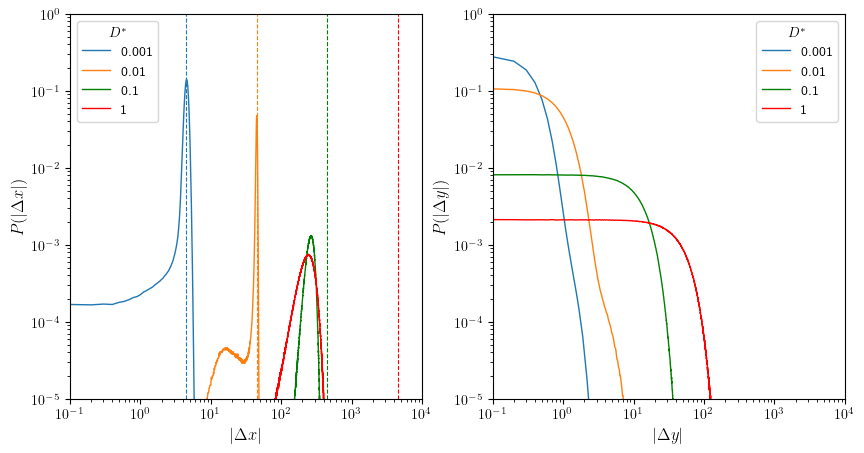

In [26]:
Rcut = [10000.0, 10000.0]
binW = [0.1, 0.1]

nr_list = [26, 38, 44, 50]
D = [1e-3, 1e-2, 0.1, 1]
ld = [4.5, 45, 450, 4500]
color = ["tab:blue", "tab:orange", "green", "red"]

fig1, ax1 = plt.subplots(1, 2, figsize = (10, 5))
lw = 1
ms = 3

ld_xavg = []
ld_yavg = []
for i in range(len(nr_list)):
    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "dispDist.dat")
    [dispData, _] = readData(fpath, 2)

    x = [binW[0]*j for j in dispData[0]]
    y = [binW[1]*j for j in dispData[2]]

    ld_xavg.append(sum([x[j]*dispData[1][j] for j in range(len(x))]))
    ld_yavg.append(sum([y[j]*dispData[3][j] for j in range(len(y))]))
    
    ax1[0].loglog(x, dispData[1], "-", lw = lw, ms = ms, color = color[i], label = "{D}".format(D = D[i]))
    ax1[0].axvline(x = ld[i], ymin = 0, ymax = 1, color = color[i], ls = "--", lw = 0.8)
    ax1[1].loglog(y, dispData[3], "-", lw = lw, ms = ms, color = color[i], label = "{D}".format(D = D[i]))

for i in range(len(ax1)):
    ax1[i].set(xlim = (binW[0], Rcut[i]), ylim = (1e-5, 1))
    ax1[i].legend(title = r"$D^*$", fontsize = 10)

ax1[0].set_xlabel(r"$|\Delta x|$", fontsize = 12)
ax1[0].set_ylabel(r"$P(|\Delta x|)$", fontsize = 12)
ax1[1].set_xlabel(r"$|\Delta y|$", fontsize = 12)
ax1[1].set_ylabel(r"$P(|\Delta y|)$", fontsize = 12)

print(ld_xavg)
print(ld_yavg)

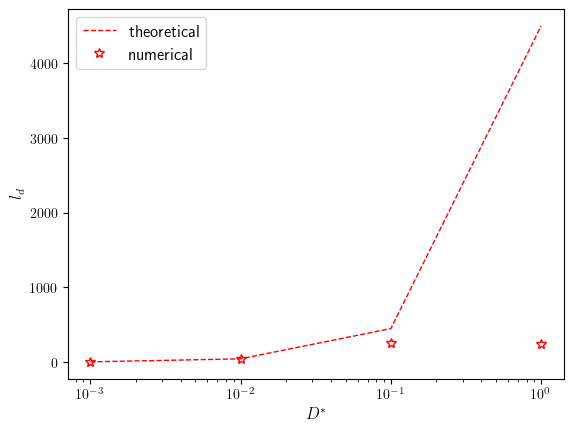

In [23]:
fig2, ax2 = plt.subplots(1, 2, figsize = (10, 5))

ax2[0].semilogx(D, ld, ls = "--", lw = 1, color = "red", label = "theoretical")
ax2[0].semilogx(D, ld_xavg, marker = "*", ms = 7, lw = 0, fillstyle = "none", color = "red", label = "numerical")
ax2[1].semilogx(D, )

ax2.set_xlabel(r"$D^*$", fontsize = 12)
ax2.set_ylabel(r"$x_d$", fontsize = 12)
ax2.legend(fontsize = 12)